In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import sklearn.metrics as skm
from tqdm import tqdm
import time
from itertools import combinations
from scipy.stats import t, sem
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import boto3
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-03-06 18:48:04.372636


### Functions

In [3]:
# prep data
def prep_data(df, list_cols):
    # get the transformations
    list_str_trans = [
        'None',
        'Log',
        'Log10',
        'Square',
        'Square_Root',
        'Cube',
        'Cube_Root',
        'Reciprocal',
    ]
    for col in tqdm(list_cols):
        for str_trans in list_str_trans:
            str_col_new = f'{col}__{str_trans}'
            if str_trans == 'None':
                df[str_col_new] = df[col]
            elif str_trans == 'Log':
                df[str_col_new] = np.log(df[col])
            elif str_trans == 'Log10':
                df[str_col_new] = np.log10(df[col])
            elif str_trans == 'Square':
                df[str_col_new] = df[col] ** 2
            elif str_trans == 'Square_Root':
                df[str_col_new] = np.sqrt(df[col])
            elif str_trans == 'Cube':
                df[str_col_new] = df[col] ** 3
            elif str_trans == 'Cube_Root':
                df[str_col_new] = np.cbrt(df[col])
            elif str_trans == 'Reciprocal':
                df[str_col_new] = 1 / df[col]
            else:
                pass
    # drop
    df.drop(list_cols, axis=1, inplace=True)
    # return
    return df

In [4]:
# get all combinations of features
def get_combinations_of_features(list_cols, int_len_min=1, int_len_max=3):
    list_tpl_cols_model = []
    for a in range(int_len_min, int_len_max+1):
        list_tpl_cols_model.extend(combinations(list_cols, a))
    # convert to lists
    list_list_cols_model = [list(tpl_cols_model) for tpl_cols_model in list_tpl_cols_model]
    # make a df
    df_cols_model = pd.DataFrame({
        'list_cols_model': list_list_cols_model},
    )
    # get the prefix
    df_cols_model['list_cols_model_prefix'] = df_cols_model['list_cols_model'].apply(
        lambda x: [col.split('__')[0] for col in x],
    )
    # check if there are duplicates
    df_cols_model['n_dups'] = df_cols_model['list_cols_model_prefix'].apply(
        lambda x: pd.Series(x).value_counts().max(),
    )
    # subset
    df_cols_model = df_cols_model[df_cols_model['n_dups'] == 1].copy()
    # subset
    list_cols = [
        'list_cols_model',
    ]
    df_cols_model = df_cols_model[list_cols].copy()
    # get list
    list_list_cols_model = list(df_cols_model['list_cols_model'])
    # return
    return list_list_cols_model

In [5]:
def train_test_split(df, flt_prop_train=0.66, int_random_state=42):
    # shuffle
    df = df.sample(frac=1, random_state=int_random_state).reset_index(drop=True)
    # get nrows
    int_nrows = df.shape[0]
    df['row'] = list(range(1, int_nrows+1))
    df['row'] = df['row'] / int_nrows
    df['data_set'] = df['row'].apply(
        lambda x: 'train' if x <= flt_prop_train else 'test',
    )
    df_train = df[df['data_set']=='train'].copy()
    df_train.drop('data_set', axis=1, inplace=True)
    df_test = df[df['data_set']=='test'].copy()
    df_test.drop('data_set', axis=1, inplace=True)
    return df_train, df_test

In [6]:
def build_linear_regression_models(df, list_list_cols_model, str_target='target', int_k_folds=10, int_random_state=42, flt_prop_train=0.75):
    # empty list
    list_dict_row = []
    # get list of cols in model
    for list_cols_model in tqdm(list_list_cols_model):
        int_random_state_start = int_random_state
        for a in range(int_k_folds):
        
            # train test split
            df_train, df_test = train_test_split(
                df=df, 
                flt_prop_train=flt_prop_train,
                int_random_state=int_random_state_start,
            )

            # initialize model
            cls_model = LinearRegression()

            # fit model on training
            try:
                cls_model.fit(
                    df_train[list_cols_model], 
                    df_train[str_target],
                )
            except ValueError as e:
                print(f'Error: {e}')
                continue

            # predict on train and test
            y_hat_train = cls_model.predict(df_train[list_cols_model])
            y_hat_test = cls_model.predict(df_test[list_cols_model])

            # get train and test scores
            flt_score_train = np.sqrt(skm.mean_squared_error(
                y_true=df_train[str_target], 
                y_pred=y_hat_train,
            ))
            flt_score_test = np.sqrt(skm.mean_squared_error(
                y_true=df_test[str_target], 
                y_pred=y_hat_test,
            ))

            # get intercept and betas
            flt_int = cls_model.intercept_
            list_coef = cls_model.coef_

            # dict_row
            dict_row = {
            'list_cols_model': list_cols_model,
            'intercept': flt_int,
            'coefficients': list_coef,
            'random_state': int_random_state_start,
            'score_train': flt_score_train,
            'score_test': flt_score_test,
            }
            # append
            list_dict_row.append(dict_row)
            # change randome state
            int_random_state_start += 1
                
    # make df
    df_results = pd.DataFrame(list_dict_row)
    # return
    return df_results

In [7]:
def extrapolate(df_results, int_days=60, int_total=720, flt_mean_train_target=0.353309):
    # map the coefficient to the column
    df_results['dict_coefficients'] = df_results.apply(
        lambda x: dict(zip(x['list_cols_model'], x['coefficients'])),
        axis=1,
    )
    # get df of coefficients
    df_coef = pd.DataFrame(list(df_results['dict_coefficients'])).fillna(0)
    df_coef.columns = [f'{col}__coef' for col in df_coef.columns]
    # concatenate
    df_results = pd.concat([df_results, df_coef], axis=1)
    # drop
    list_cols = [
        'coefficients',
        'dict_coefficients',
    ]
    df_results.drop(list_cols, axis=1, inplace=True)
    # dict row
    dict_row = {
        'days_delinquent': [int_days],
        'days_total': [int_total],
        'mean_train_target': [flt_mean_train_target],
    }
    # make df
    df = pd.DataFrame(dict_row)
    # prep data
    list_cols = list(df.columns)
    df = prep_data(
        df=df,
        list_cols=list_cols,
    )
    # add suffix
    list_cols = [f'{col}__coef' for col in df.columns]
    df.columns = list_cols
    # convert to dict
    dict_prod = df.to_dict(orient='records')[0]
    # extrapolate
    list_str_col = ['intercept']
    a = 0
    for key, val in tqdm(dict_prod.items()):
        # create new col
        str_col = f'col_{a}'
        df_results[str_col] = df_results[key] * val
        # append
        list_str_col.append(str_col)
        a += 1
    # get the sum
    df_results['production_prediction'] = df_results[list_str_col].sum(axis=1)
    # rm intercept
    list_cols = [col for col in list_str_col if col != 'intercept']
    df_results.drop(list_cols, axis=1, inplace=True)
    # return
    return df_results

In [8]:
def get_confidence_interval(list_values, flt_confidence=0.95):
    int_length = len(list_values)
    int_df = int_length - 1
    flt_mean = np.mean(list_values)
    flt_se = sem(list_values)  
    flt_q = (1 + flt_confidence) / 2
    flt_margin = flt_se * t.ppf(q=flt_q, df=int_df)
    flt_lower = flt_mean - flt_margin
    flt_upper = flt_mean + flt_margin
    dict_ci = {'lower': flt_lower, 'mean': flt_mean, 'upper': flt_upper}
    return dict_ci

In [9]:
def aggregate_results(df_results):
    # group
    df_results['list_cols_model'] = df_results['list_cols_model'].astype(str)
    df_grouped = df_results.groupby(by='list_cols_model', as_index=False).agg(list)
    # get confidence intervals for productionPrediction
    df_grouped['dict_ci_production_prediction'] = df_grouped['production_prediction'].apply(get_confidence_interval)
    # overwrite cols with means
    for col in tqdm(df_grouped.columns):
        try:
            df_grouped[col] = df_grouped[col].apply(np.mean)
        except Exception as e:
            pass
    # extract upper and lower ci
    str_col = 'dict_ci_production_prediction'
    for str_key in tqdm(['lower','mean','upper']):
        # lower and upper
        df_grouped[f'{str_col.split("_")[-1]}_{str_key}'] = df_grouped[str_col].apply(
            lambda x: x[str_key],
        )
    # drop
    list_cols = [
        'production_prediction',
        'dict_ci_production_prediction',
    ]
    df_grouped.drop(list_cols, axis=1, inplace=True)
    # make list cols model into a list
    df_grouped['list_cols_model'] = df_grouped['list_cols_model'].apply(eval)
    # return
    return df_grouped

In [10]:
def get_output(dict_row, flt_mean_train_target=0.353309):
    # get intercept
    flt_intercept = dict_row['intercept']
    # get the features and corresponding transformation
    list_cols_model = dict_row['list_cols_model']
    dict_cols_coef = {}
    for col in tqdm(list_cols_model):
        # get the coefficient
        flt_coef = dict_row[f'{col}__coef']
        # assign
        dict_cols_coef[col] = flt_coef
    # make formula
    str_formula = f'{flt_intercept:0.4f}'
    for key, val in tqdm(dict_cols_coef.items()):
        str_formula_tmp = f' + ({key} * {val:0.7f})'
        str_formula += str_formula_tmp
    # get test score
    flt_score_test = dict_row['score_test']
    str_score = f'Test RMSE = {flt_score_test:0.4f}'
    # get scores
    flt_score_train = dict_row['score_train']
    flt_score_test = dict_row['score_test']
    # get predictions
    flt_lower = dict_row['prediction_lower']
    flt_mean = dict_row['prediction_mean']
    flt_upper = dict_row['prediction_upper']
    str_predictions = f'{flt_mean:0.4f} (95% CI: {flt_lower:0.4f}, {flt_upper:0.4f})'
    # get factors
    flt_lower_factor = flt_lower / flt_mean_train_target
    flt_mean_factor = flt_mean / flt_mean_train_target
    flt_upper_factor = flt_upper / flt_mean_train_target
    str_factors = f'{flt_mean_factor:0.4f} (Range: {flt_lower_factor:0.4f}, {flt_upper_factor:0.4f})'
    # print output
    print(f'Formula: {str_formula}')
    print(f'Train RMSE: {flt_score_train:0.4f}')
    print(f'Test RMSE: {flt_score_test:0.4f}')
    print(f'Predictions: {str_predictions}')
    print(f'Factors: {str_factors}')
    print('')

In [11]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [12]:
# get tier
def get_tier(fltDebtorScore):
    if fltDebtorScore <= 0.04:
        return 'A1'
    elif fltDebtorScore <= 0.07:
        return 'A'
    elif fltDebtorScore <= 0.14:
        return 'B'
    elif fltDebtorScore <= 0.17:
        return 'C'
    elif fltDebtorScore <= 0.2015:
        return 'D'
    else:
        return 'Decline'

### Constants

In [13]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
str_target = 'mean_prod_actual'
str_variant = 'noPTImodel7'
int_k_folds = 50
flt_lgd_constant = 0.4324
flt_intercept_mike = -0.03281
flt_coef_mike = 1.95553

Project: 20231010-gen-xii


### Output directory

In [14]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [15]:
str_filename = 'df_summary.csv'
str_local_path = f'../../01_all/01_data_collection/output/{str_variant}/{str_filename}'
list_cols = [
    'days_delinquent',
    'days_total',
    'mean_train_target',
    str_target,
]
df = pd.read_csv(str_local_path, usecols=list_cols)
dict_rename = {
    'mean_prod_actual': 'target',
}
df.rename(columns=dict_rename, inplace=True)
list_cols = [
    'days_delinquent',
    'days_total',
    'mean_train_target',
    'target',
]
df = df[list_cols].copy()

# show
df

,days_delinquent,days_total,mean_train_target,target
0,1,30,0.198421,0.004085
1,1,60,0.363205,0.443627
2,1,90,0.482715,0.610498
3,1,120,0.565997,0.719975
4,1,150,0.626327,0.783905
...,...,...,...,...
110,90,600,0.111380,0.346609
111,90,630,0.120001,0.362337
112,90,660,0.128267,0.378676
113,90,690,0.137311,0.384600


### Prep data

In [16]:
# get columns
list_cols = [col for col in df.columns if col != 'target']

# prep data
df = prep_data(
    df=df,
    list_cols=list_cols,
)

df

100%|██████████| 3/3 [00:00<00:00, 333.87it/s]


,target,days_delinquent__None,days_delinquent__Log,days_delinquent__Log10,days_delinquent__Square,days_delinquent__Square_Root,days_delinquent__Cube,days_delinquent__Cube_Root,days_delinquent__Reciprocal,days_total__None,...,days_total__Cube_Root,days_total__Reciprocal,mean_train_target__None,mean_train_target__Log,mean_train_target__Log10,mean_train_target__Square,mean_train_target__Square_Root,mean_train_target__Cube,mean_train_target__Cube_Root,mean_train_target__Reciprocal
0,0.004085,1,0.00000,0.000000,1,1.000000,1,1.000000,1.000000,30,...,3.107233,0.033333,0.198421,-1.617362,-0.702411,0.039371,0.445445,0.007812,0.583261,5.039778
1,0.443627,1,0.00000,0.000000,1,1.000000,1,1.000000,1.000000,60,...,3.914868,0.016667,0.363205,-1.012787,-0.439848,0.131918,0.602665,0.047913,0.713484,2.753264
2,0.610498,1,0.00000,0.000000,1,1.000000,1,1.000000,1.000000,90,...,4.481405,0.011111,0.482715,-0.728328,-0.316309,0.233014,0.694777,0.112480,0.784447,2.071614
3,0.719975,1,0.00000,0.000000,1,1.000000,1,1.000000,1.000000,120,...,4.932424,0.008333,0.565997,-0.569167,-0.247186,0.320352,0.752327,0.181318,0.827189,1.766795
4,0.783905,1,0.00000,0.000000,1,1.000000,1,1.000000,1.000000,150,...,5.313293,0.006667,0.626327,-0.467882,-0.203199,0.392286,0.791409,0.245700,0.855593,1.596609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,0.346609,90,4.49981,1.954243,8100,9.486833,729000,4.481405,0.011111,600,...,8.434327,0.001667,0.111380,-2.194805,-0.953192,0.012406,0.333737,0.001382,0.481138,8.978254
111,0.362337,90,4.49981,1.954243,8100,9.486833,729000,4.481405,0.011111,630,...,8.572619,0.001587,0.120001,-2.120252,-0.920814,0.014400,0.346412,0.001728,0.493244,8.333239
112,0.378676,90,4.49981,1.954243,8100,9.486833,729000,4.481405,0.011111,660,...,8.706588,0.001515,0.128267,-2.053643,-0.891886,0.016452,0.358144,0.002110,0.504318,7.796250
113,0.384600,90,4.49981,1.954243,8100,9.486833,729000,4.481405,0.011111,690,...,8.836556,0.001449,0.137311,-1.985504,-0.862294,0.018854,0.370555,0.002589,0.515904,7.282719


### Get every combination of features

In [17]:
list_cols = [col for col in df.columns if col != 'target']

list_list_cols_model = get_combinations_of_features(
    list_cols=list_cols,
    int_len_min=1, 
    int_len_max=3,
)
int_n_combinations = len(list_list_cols_model)
print(f'There are {int_n_combinations} unique combinations of features')

There are 728 unique combinations of features


### Build linear regression models

In [18]:
df_results = build_linear_regression_models(
    df=df, 
    list_list_cols_model=list_list_cols_model, 
    str_target='target', 
    int_k_folds=int_k_folds, 
    int_random_state=42, 
    flt_prop_train=0.75,
)
df_results

100%|██████████| 728/728 [05:03<00:00,  2.40it/s]


,list_cols_model,intercept,coefficients,random_state,score_train,score_test
0,[days_delinquent__None],0.734961,[-0.00641792582420457],42,0.208540,0.165030
1,[days_delinquent__None],0.727966,[-0.006171844288882437],43,0.203227,0.183741
2,[days_delinquent__None],0.708260,[-0.005931444903503788],44,0.211621,0.155636
3,[days_delinquent__None],0.725917,[-0.006250802181686802],45,0.202755,0.185195
4,[days_delinquent__None],0.738094,[-0.006190063889132389],46,0.204655,0.180287
...,...,...,...,...,...,...
36395,"[days_delinquent__Reciprocal, days_total__Reci...",0.522449,"[0.4596777364898924, -27.15407027519759, 0.000...",87,0.159429,0.171409
36396,"[days_delinquent__Reciprocal, days_total__Reci...",0.513896,"[0.46506436834728043, -25.006972539919683, -0....",88,0.151478,0.364708
36397,"[days_delinquent__Reciprocal, days_total__Reci...",0.489446,"[0.49719114250345536, -27.39355333258091, 0.00...",89,0.167451,0.142052
36398,"[days_delinquent__Reciprocal, days_total__Reci...",0.515893,"[0.4537152559471204, -22.612264229561788, -0.0...",90,0.149900,0.357420


### Get the Gen XII score for each model

In [19]:
str_filename = 'df_train_noleaks_pre.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
df_tmp['uniqueid'] = df_tmp['uniqueid'].astype(int)
df_tmp.drop_duplicates(subset='uniqueid', keep='last', inplace=True)
# get mean of target
flt_mean_train_target = df_tmp['target'].mean()
print(f'Mean of target in training data: {flt_mean_train_target:0.4f}')

Mean of target in training data: 0.3614


In [20]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df_tmp['yhat'] = cls_model_inference.predict_proba(df_tmp[list_cols_model])[:, 1]
# show
df_tmp

,linkf060__tu,linkf045__tu,linkf185__tu,linkf193__tu,linkf195__tu,linkf105__tu,linkf032__tu,linkf020__tu,linkf075__tu,linkf084__tu,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,target,yhat
1,0.0,0.0,152.0,40.0,1141.0,40.0,n,0.0,0.0,1.0,...,2013,1.256262,10,4,0.09,1.370370,4.0,1.284932,1,0.513062
3,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,...,2013,1.256262,10,4,0.15,1.586207,2.0,1.569863,1,0.310533
5,0.0,0.0,5.0,5.0,1802.0,5.0,n,27.0,2.0,1.0,...,2013,1.256262,10,4,0.03,1.342857,1.0,3.961644,1,0.706639
6,0.0,0.0,30.0,30.0,1149.0,6.0,n,34.0,1.0,1.0,...,2013,1.256262,10,4,0.12,1.588235,2.0,0.838356,1,0.448451
7,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,...,2013,1.256262,10,4,0.12,1.037037,0.0,3.613699,0,0.241002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74583,0.0,0.0,0.0,152.0,1641.0,152.0,n,0.0,0.0,0.0,...,2016,1.219360,3,1,0.15,1.482759,1.0,12.701370,1,0.689931
74584,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,...,2016,1.219360,3,1,0.15,1.222222,3.0,8.498630,1,0.172488
74586,0.0,0.0,0.0,0.0,0.0,0.0,nan,0.0,0.0,0.0,...,2016,1.219360,3,1,0.09,1.343750,1.0,3.890411,0,0.240983
74587,0.0,0.0,1912.0,1912.0,1948.0,1613.0,n,0.0,0.0,0.0,...,2016,1.219360,3,1,0.09,1.240000,5.0,4.030137,0,0.310571


In [21]:
# get ecnl
df_tmp['ecnl'] = df_tmp['yhat'] * flt_lgd_constant
# get modified ecnl
df_tmp['ecnl_mod'] = flt_intercept_mike + (flt_coef_mike * df_tmp['ecnl'])
# get tier
df_tmp['tier'] = df_tmp['ecnl_mod'].apply(get_tier)
# subset
list_cols = [
    'intopenbktype__app',
    'tier',
    'target',
]
df_tmp = df_tmp[list_cols].copy()
# show
df_tmp

,intopenbktype__app,tier,target
1,nan,Decline,1
3,7.0,Decline,1
5,nan,Decline,1
6,nan,Decline,1
7,7.0,D,0
...,...,...,...
74583,7.0,Decline,1
74584,7.0,B,1
74586,nan,D,0
74587,13.0,Decline,0


In [22]:
# subset
df_tmp = df_tmp[df_tmp['tier'] == 'D'].copy()
df_tmp

,intopenbktype__app,tier,target
7,7.0,D,0
25,nan,D,0
26,nan,D,0
28,7.0,D,0
45,7.0,D,0
...,...,...,...
74502,7.0,D,0
74527,nan,D,0
74563,7.0,D,0
74579,13.0,D,0


In [23]:
# # subset
# df_tmp = df_tmp[df_tmp['intopenbktype__app'] == '7.0'].copy()
# df_tmp

In [24]:
# get mean of target
flt_mean_train_target = df_tmp['target'].mean()
print(f'Mean of target in training data: {flt_mean_train_target:0.4f}')

Mean of target in training data: 0.1930


In [25]:
int_days = 60 # 60+ DPD
int_total = 720 # 24 months (24 * 30)

df_results = extrapolate(
    df_results=df_results, 
    int_days=int_days, 
    int_total=int_total, 
    flt_mean_train_target=flt_mean_train_target,
)
int_n_models = df_results.shape[0]
df_results

100%|██████████| 24/24 [00:00<00:00, 2030.65it/s]


,list_cols_model,intercept,random_state,score_train,score_test,days_delinquent__None__coef,days_delinquent__Log__coef,days_delinquent__Log10__coef,days_delinquent__Square__coef,days_delinquent__Square_Root__coef,...,days_total__Reciprocal__coef,mean_train_target__None__coef,mean_train_target__Log__coef,mean_train_target__Log10__coef,mean_train_target__Square__coef,mean_train_target__Square_Root__coef,mean_train_target__Cube__coef,mean_train_target__Cube_Root__coef,mean_train_target__Reciprocal__coef,production_prediction
0,[days_delinquent__None],0.734961,42,0.208540,0.165030,-0.006418,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.349886
1,[days_delinquent__None],0.727966,43,0.203227,0.183741,-0.006172,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.357656
2,[days_delinquent__None],0.708260,44,0.211621,0.155636,-0.005931,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.352373
3,[days_delinquent__None],0.725917,45,0.202755,0.185195,-0.006251,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.350868
4,[days_delinquent__None],0.738094,46,0.204655,0.180287,-0.006190,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.366690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36395,"[days_delinquent__Reciprocal, days_total__Reci...",0.522449,87,0.159429,0.171409,0.000000,0.0,0.0,0.0,0.0,...,-27.154070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000115,0.492991
36396,"[days_delinquent__Reciprocal, days_total__Reci...",0.513896,88,0.151478,0.364708,0.000000,0.0,0.0,0.0,0.0,...,-25.006973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.000753,0.483012
36397,"[days_delinquent__Reciprocal, days_total__Reci...",0.489446,89,0.167451,0.142052,0.000000,0.0,0.0,0.0,0.0,...,-27.393553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000151,0.460469
36398,"[days_delinquent__Reciprocal, days_total__Reci...",0.515893,90,0.149900,0.357420,0.000000,0.0,0.0,0.0,0.0,...,-22.612264,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.000760,0.488108


### Aggregate results

In [26]:
%%time

df_grouped = aggregate_results(
    df_results=df_results,
)
df_grouped

100%|██████████| 3/3 [00:00<00:00, 1606.40it/s]

CPU times: user 1.11 s, sys: 24 ms, total: 1.14 s
Wall time: 1.14 s


,list_cols_model,intercept,random_state,score_train,score_test,days_delinquent__None__coef,days_delinquent__Log__coef,days_delinquent__Log10__coef,days_delinquent__Square__coef,days_delinquent__Square_Root__coef,...,mean_train_target__Log__coef,mean_train_target__Log10__coef,mean_train_target__Square__coef,mean_train_target__Square_Root__coef,mean_train_target__Cube__coef,mean_train_target__Cube_Root__coef,mean_train_target__Reciprocal__coef,prediction_lower,prediction_mean,prediction_upper
0,"[days_delinquent__Cube, days_total__Cube, mean...",0.393624,66.5,0.137235,0.144148,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.788672,0.00000,0.000000,0.623623,0.628199,0.632776
1,"[days_delinquent__Cube, days_total__Cube, mean...",-0.152081,66.5,0.062259,0.060222,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.11409,0.000000,0.553175,0.555054,0.556933
2,"[days_delinquent__Cube, days_total__Cube, mean...",0.807398,66.5,0.103403,0.115139,0.0,0.0,0.0,0.0,0.0,...,0.157835,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.602042,0.606300,0.610558
3,"[days_delinquent__Cube, days_total__Cube, mean...",0.807398,66.5,0.103403,0.115139,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.363429,0.000000,0.000000,0.000000,0.00000,0.000000,0.602042,0.606300,0.610558
4,"[days_delinquent__Cube, days_total__Cube, mean...",0.253265,66.5,0.090596,0.095638,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.564947,0.567487,0.570028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,[mean_train_target__Log10],0.851214,66.5,0.112396,0.124676,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.420846,0.000000,0.000000,0.000000,0.00000,0.000000,0.549084,0.550503,0.551922
724,[mean_train_target__None],0.233207,66.5,0.112322,0.116126,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.413332,0.415196,0.417059
725,[mean_train_target__Reciprocal],0.523306,66.5,0.259828,0.492724,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,-0.001175,0.511136,0.517215,0.523295
726,[mean_train_target__Square],0.348630,66.5,0.164332,0.169538,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.962321,0.000000,0.000000,0.00000,0.000000,0.381638,0.384460,0.387281


### Sort by best test metric

In [27]:
df_grouped.sort_values(by='score_test', ascending=True, inplace=True)
get_output(
    dict_row=df_grouped.iloc[0].to_dict(),
    flt_mean_train_target=flt_mean_train_target,
)
df_grouped

100%|██████████| 3/3 [00:00<00:00, 28276.21it/s]


Formula: -0.0725 + (days_delinquent__Reciprocal * -0.2704569) + (days_total__Square * -0.0000001) + (mean_train_target__Square_Root * 1.3995354)
Train RMSE: 0.0386
Test RMSE: 0.0400
Predictions: 0.5055 (95% CI: 0.5042, 0.5067)
Factors: 2.6196 (Range: 2.6132, 2.6261)



,list_cols_model,intercept,random_state,score_train,score_test,days_delinquent__None__coef,days_delinquent__Log__coef,days_delinquent__Log10__coef,days_delinquent__Square__coef,days_delinquent__Square_Root__coef,...,mean_train_target__Log__coef,mean_train_target__Log10__coef,mean_train_target__Square__coef,mean_train_target__Square_Root__coef,mean_train_target__Cube__coef,mean_train_target__Cube_Root__coef,mean_train_target__Reciprocal__coef,prediction_lower,prediction_mean,prediction_upper
466,"[days_delinquent__Reciprocal, days_total__Squa...",-0.072453,66.5,0.038611,0.039990,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.399535,0.0,0.0,0.000000,0.504233,0.505479,0.506724
412,"[days_delinquent__Reciprocal, days_total__Cube...",-0.073887,66.5,0.038553,0.040022,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.395132,0.0,0.0,0.000000,0.500870,0.502381,0.503891
448,"[days_delinquent__Reciprocal, days_total__None...",-0.067458,66.5,0.038988,0.040108,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.391737,0.0,0.0,0.000000,0.511878,0.512977,0.514076
484,"[days_delinquent__Reciprocal, mean_train_targe...",-0.070533,66.5,0.039348,0.040145,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.357649,0.0,0.0,0.000000,0.520763,0.521709,0.522655
475,"[days_delinquent__Reciprocal, days_total__Squa...",-0.065742,66.5,0.039261,0.040371,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.370443,0.0,0.0,0.000000,0.517946,0.519289,0.520633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,"[days_total__None, mean_train_target__Reciprocal]",0.284162,66.5,0.233611,0.396256,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,-0.000811,0.697597,0.704733,0.711870
707,"[days_total__Square, mean_train_target__Recipr...",0.386810,66.5,0.237458,0.416328,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,-0.000909,0.724364,0.732772,0.741180
653,"[days_total__Cube, mean_train_target__Reciprocal]",0.425596,66.5,0.240806,0.431813,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,-0.000971,0.738134,0.747278,0.756421
698,"[days_total__Reciprocal, mean_train_target__Re...",0.600740,66.5,0.241747,0.441092,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,-0.000751,0.564092,0.568574,0.573056


### Plot distribution of mean predictions

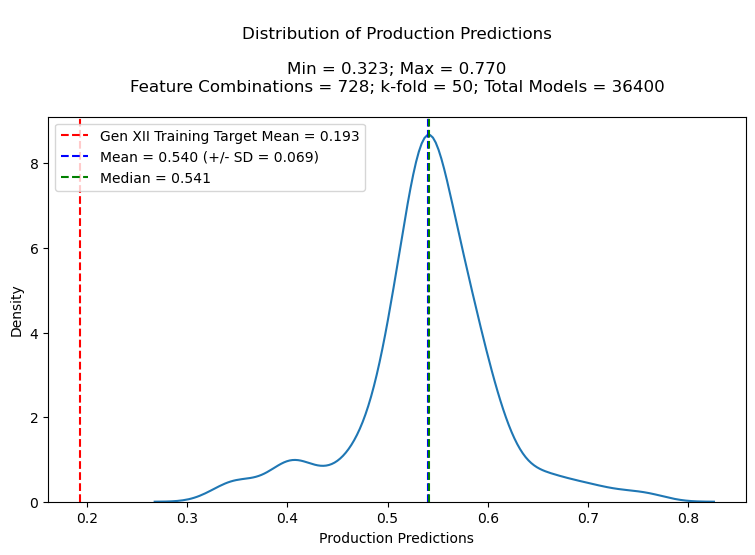

In [28]:
str_col = 'prediction_mean'
int_n = df_grouped.shape[0]
flt_min = df_grouped[str_col].min()
flt_max = df_grouped[str_col].max()
flt_mean = df_grouped[str_col].mean()
flt_sd = df_grouped[str_col].std()
flt_mdn = df_grouped[str_col].median()
str_title = f"""
Distribution of Production Predictions

Min = {flt_min:0.3f}; Max = {flt_max:0.3f}
Feature Combinations = {int_n_combinations}; k-fold = {int_k_folds}; Total Models = {int_n_models}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('Production Predictions')
sns.kdeplot(list(df_grouped[str_col]), ax=ax)
# add vertical line
ax.axvline(x=flt_mean_train_target, color='r', linestyle='--', label=f'Gen XII Training Target Mean = {flt_mean_train_target:0.3f}')
ax.axvline(x=flt_mean, color='b', linestyle='--', label=f'Mean = {flt_mean:0.3f} (+/- SD = {flt_sd:0.3f})')
ax.axvline(x=flt_mdn, color='g', linestyle='--', label=f'Median = {flt_mdn:0.3f}')
# legend
plt.legend()
# show
plt.show()

### Plot distribution of test RMSE

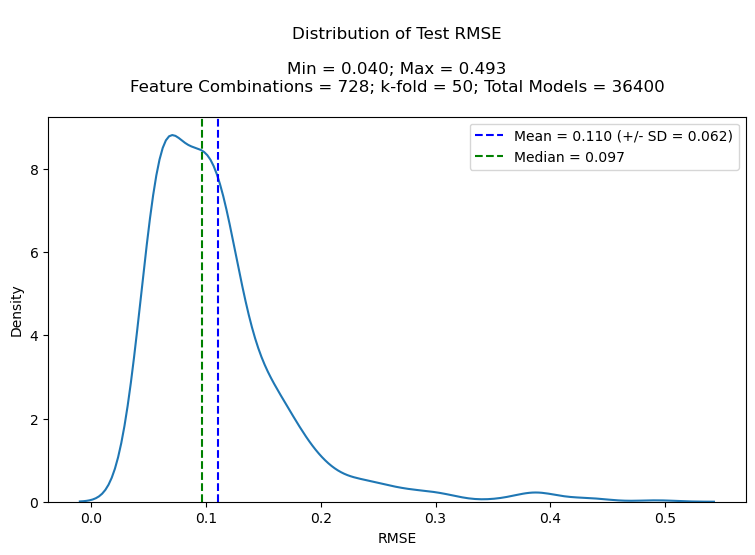

In [29]:
str_col = 'score_test'
int_n = df_grouped.shape[0]
flt_min = df_grouped[str_col].min()
flt_max = df_grouped[str_col].max()
flt_mean = df_grouped[str_col].mean()
flt_sd = df_grouped[str_col].std()
flt_mdn = df_grouped[str_col].median()
str_title = f"""
Distribution of Test RMSE

Min = {flt_min:0.3f}; Max = {flt_max:0.3f}
Feature Combinations = {int_n_combinations}; k-fold = {int_k_folds}; Total Models = {int_n_models}
"""
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
ax.set_xlabel('RMSE')
# plot
sns.kdeplot(df_grouped[str_col], ax=ax)
# add vertical line
ax.axvline(x=flt_mean, color='b', linestyle='--', label=f'Mean = {flt_mean:0.3f} (+/- SD = {flt_sd:0.3f})')
ax.axvline(x=flt_mdn, color='g', linestyle='--', label=f'Median = {flt_mdn:0.3f}')
# legend
plt.legend()

plt.show()